In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter

In [2]:
data = pd.read_csv("./data/gen_regression.csv")

In [3]:
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


In [4]:
X = data.x
y = data.y

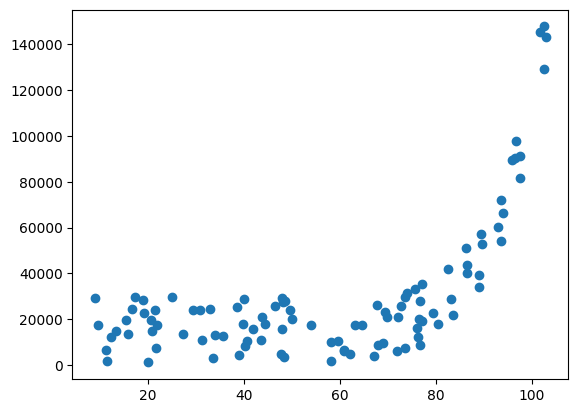

In [5]:
plt.scatter(X, y)

In [6]:
from sklearn.linear_model import LinearRegression
X = pd.DataFrame(X)
t1 = perf_counter()
linear = LinearRegression().fit(X, y)
perf_counter() - t1

0.002158113002224127

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


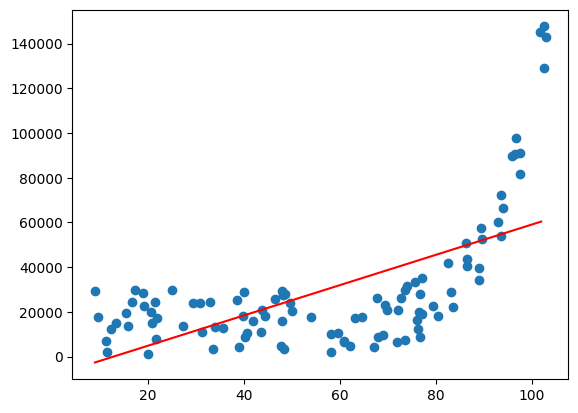

In [7]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

In [8]:
linear.score(X, y)

0.37467360318911636

In [9]:
from sklearn.preprocessing import PolynomialFeatures
transformation = PolynomialFeatures(degree=2)

In [10]:
t1 = perf_counter()
transformation.fit(X)
X_2 = transformation.transform(X)
perf_counter()-t1

0.0020103010028833523

In [11]:
print(X_2.shape)
X_2[:5]

(100, 3)


array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

In [12]:
t1 = perf_counter()
poly_2d = LinearRegression().fit(X_2, y)
perf_counter() - t1

0.0009591829984856304

In [13]:
xx_2d = transformation.transform(pd.DataFrame(xx))

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


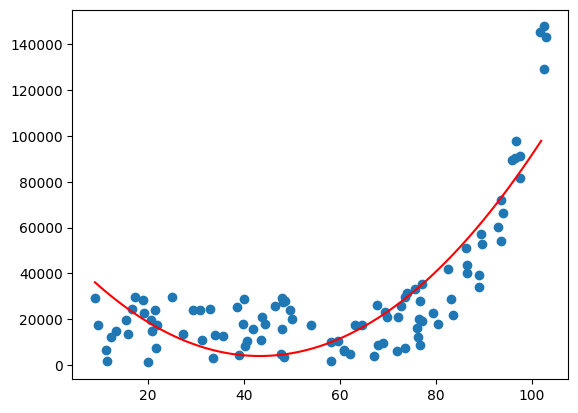

In [14]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

In [15]:
poly_2d.score(X_2, y)

0.7359753787024842

In [16]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)

In [17]:
y = data.y
X = data.drop(["y"], axis=1)

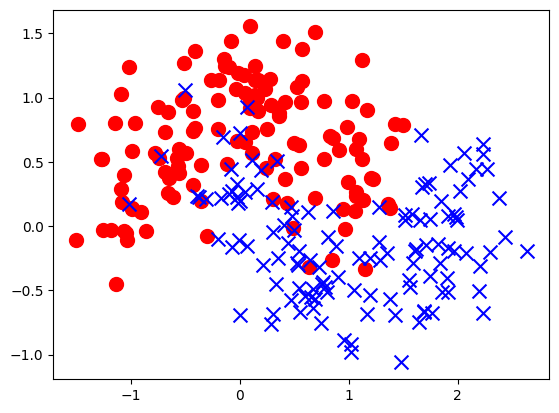

In [18]:
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [19]:
from sklearn.linear_model import LogisticRegression
t1 = perf_counter()
logistic = LogisticRegression().fit(X, y)
perf_counter() - t1

0.004140623001148924

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


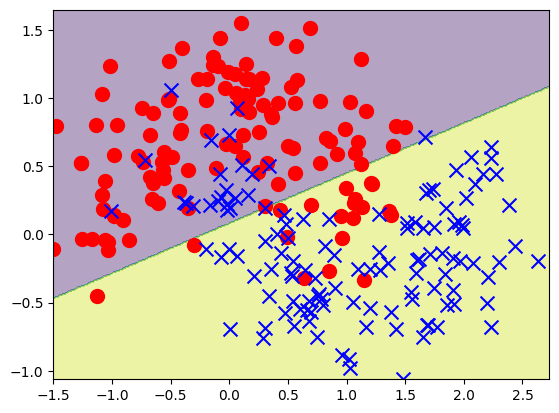

In [20]:
xx, yy = np.meshgrid(
    np.arange(X.min()['x1'], X.max()['x1']+0.1, 0.01),
    np.arange(X.min()['x2'], X.max()['x2']+0.1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [21]:
logistic.score(X, y)

0.832

In [22]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)

In [23]:
X_3.shape

(250, 9)

In [24]:
t1 = perf_counter()
class_3 = LogisticRegression().fit(X_3, y)
perf_counter() - t1

0.0033703080007398967

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


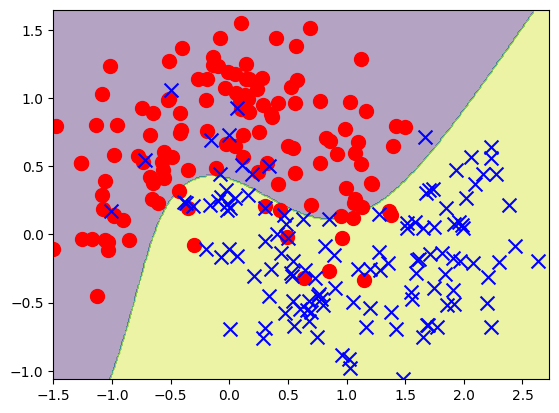

In [25]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [26]:
class_3.score(X_3, y)

0.9

In [27]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

In [28]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [29]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

In [30]:
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

In [31]:
t1 = perf_counter()
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
reg_kc_multiple.score(X_kc_prices, y_kc_prices)
perf_counter() - t1

0.014469279998593265

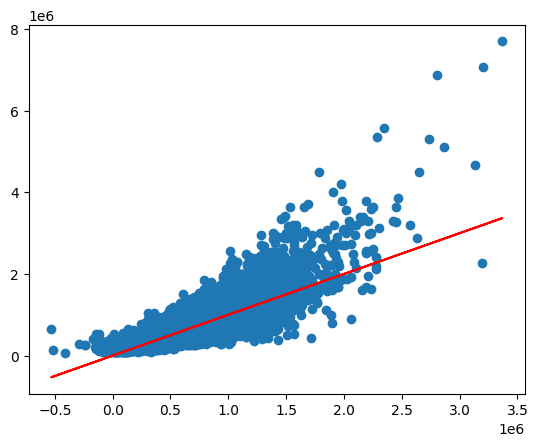

In [32]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

In [33]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)

In [34]:
X_3_kc_prices.shape

(21613, 1330)

In [35]:
t1 = perf_counter()
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
print(perf_counter() - t1)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

2.173075536000397


0.8326020796592745

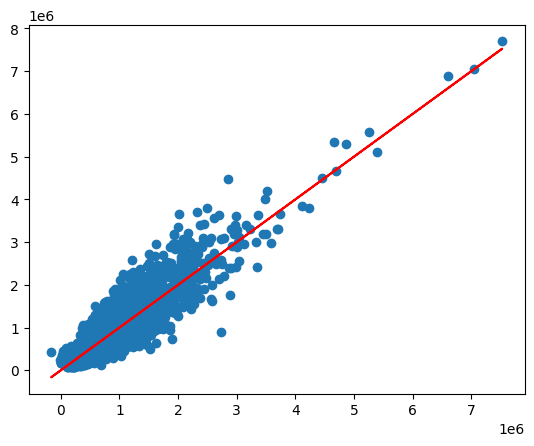

In [36]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

# EXTRA TASKS
# 1 is done
# 2

In [37]:
data_genr = pd.read_csv("./data/gen_regression.csv")
data_genr.shape

(100, 3)

In [38]:
data_genr.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


In [39]:
y_gen_regr_values = data_genr.y.to_frame()
X_gen_regr_values = data_genr.x.to_frame()

In [40]:
models_gen_regr = {}

for degree in [5, 10, 100]:
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X_gen_regr_values)

    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y_gen_regr_values)
    t2 = perf_counter()

    models_gen_regr[degree] = model

    print(t2-t1)
    print(f"score of degree {degree}:")
    print(model.score(X_poly, y_gen_regr_values))
    print()


0.0013048699984210543
score of degree 5:
0.9217478060447014

0.001252071000635624
score of degree 10:
0.9222468251462042

0.0018306609999854118
score of degree 100:
0.7924620004455778



# 3

In [43]:
models_kc = {}

for degree in [2, 3, 4]:  # anything larger is too slow
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X_kc_prices)

    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y_kc_prices)
    t2 = perf_counter()

    models_kc[degree] = model

    print(t2-t1)
    print(f"score of degree {degree}:")
    print(model.score(X_poly, y_kc_prices))
    print()


0.2898181599994132
score of degree 2:
0.808449610778652

2.388055881001492
score of degree 3:
0.8326020796592745

140.42156370099838
score of degree 4:
0.8246040350530679



In [45]:
models_kc = {}

for degree in [5, 10, 100]:
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X)

    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y)
    t2 = perf_counter()

    models_kc[degree] = model

    print(t2-t1)
    print(f"score of degree {degree}:")
    print(model.score(X_poly, y))
    print()


0.0008515909976267722
score of degree 5:
0.6755976386755242

0.0016595810011494905
score of degree 10:
0.7439555827260855

0.1481029499991564
score of degree 100:
0.04708994395522337



In [48]:
data_genc = pd.read_csv("./data/gen_classification.csv")
data_genc.head()

,Unnamed: 0,x1,x2,y
0,0,0.048289,0.267592,1
1,1,1.363151,0.171123,0
2,2,-0.424253,0.893937,0
3,3,0.112344,0.565672,0
4,4,-1.262453,0.521735,0


In [49]:
y_genc = data_genc.y
X_genc = data_genc.drop(["y"], axis=1)

In [50]:
models_genc = {}

for degree in [5, 10, 100]:
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X_genc)

    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y_genc)
    t2 = perf_counter()

    models_genc[degree] = model

    print(t2-t1)
    print(f"score of degree {degree}:")
    print(model.score(X_poly, y_genc))
    print()


0.0016688599971530493
score of degree 5:
0.7043328968861223

0.009394661999976961
score of degree 10:
0.43395980072141793

6.292861191002885
score of degree 100:
0.05610060279113971



# 4

In [ ]:
times = {}
scores = {}

for degree in [5, 10, 100]:
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X)

    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y)
    t2 = perf_counter()

    times[degree] = t2 - t1
    scores[degree] = model.score(X_poly, y)

summary_reg = pd.DataFrame({
    "degree": list(times.keys()),
    "train_time": list(times.values()),
    "accuracy": list(scores.values())
})
print("generic regression results:")
display(summary_reg)

times_kc = {}
scores_kc = {}

for degree in [1, 2, 3]:
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X_kc_prices)

    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y_kc_prices)
    t2 = perf_counter()

    times_kc[degree] = t2 - t1
    scores_kc[degree] = model.score(X_poly, y_kc_prices)

summary_kc = pd.DataFrame({
    "degree": list(times_kc.keys()),
    "train_time": list(times_kc.values()),
    "accuracy": list(scores_kc.values())
})
print("\nKC house prices results:")
display(summary_kc)

times_genc = {}
scores_genc = {}

for degree in [5, 10, 100]:
    X_poly = PolynomialFeatures(degree=degree).fit_transform(X_genc)  # X_genc, y_genc from earlier
    t1 = perf_counter()
    model = LinearRegression().fit(X_poly, y_genc)
    t2 = perf_counter()

    times_genc[degree] = t2 - t1
    scores_genc[degree] = model.score(X_poly, y_genc)

summary_genc = pd.DataFrame({
    "degree": list(times_genc.keys()),
    "train_time": list(times_genc.values()),
    "accuracy": list(scores_genc.values())
})
print("\ngeneric classification results:")
display(summary_genc)

generic regression results:


,degree,train_time,accuracy
0,5,0.002562,0.675598
1,10,0.002796,0.743956
2,100,0.148352,0.047090



KC house prices results:


,degree,train_time,accuracy
0,1,0.011662,0.699747
1,2,0.245857,0.808450
2,3,2.308174,0.832602



generic classification results:


,degree,train_time,accuracy
0,5,0.001846,0.704333
1,10,0.007319,0.433960
2,100,6.155548,0.056101


# 5, 6

In [ ]:
print("linear regression (original features):")
for name, coef in zip(X_kc_prices.columns, reg_kc_multiple.coef_):
    print(f"  {name:20s} : {coef:.4f}")
print(f"intercept : {reg_kc_multiple.intercept_:.4f}\n")


poly_names = poly_features_kc_prices.get_feature_names_out(X_kc_prices.columns)
print("polynomial regression coefficients:")
for name, coef in sorted(zip(poly_names, reg_poly2_kc.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:60s} : {coef:.4f}")
print(f"intercept : {reg_poly2_kc.intercept_:.4f}")

linear regression (original features):
  bedrooms             : -35766.5414
  bathrooms            : 41144.2785
  sqft_living          : 110.4429
  sqft_lot             : 0.1286
  floors               : 6689.5501
  waterfront           : 582960.4584
  view                 : 52870.9424
  condition            : 26385.6491
  grade                : 95890.4452
  sqft_above           : 70.7852
  sqft_basement        : 39.6576
  yr_built             : -2620.2232
  yr_renovated         : 19.8126
  zipcode              : -582.4199
  lat                  : 602748.2264
  long                 : -214729.8283
  sqft_living15        : 21.6814
  sqft_lot15           : -0.3826
intercept : 6690324.6031

polynomial regression (degree 3) coefficients:
  sqft_living^2 long                                           : -0.0575
  sqft_living sqft_above long                                  : -0.0467
  yr_built zipcode long                                        : 0.0424
  sqft_above^2 long                     